/tmp/ipykernel_2638/2144067055.py:111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


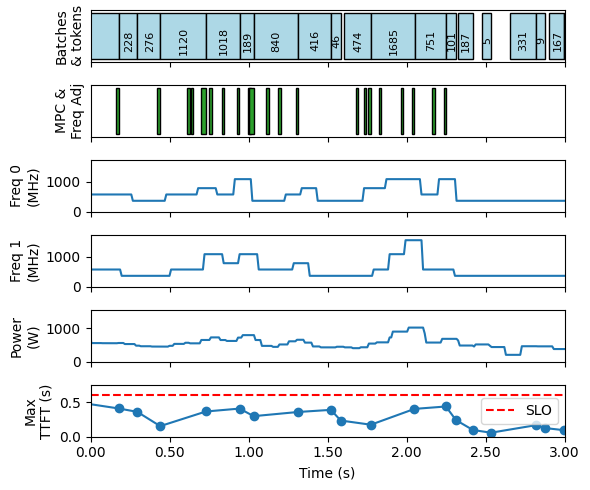

In [1]:
from matplotlib import patches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

folder = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/micro_study/profiler_logs_Dec21_micro_study_logs/meta-llama/Llama-3.3-70B-Instruct/H100/2xTP2Prefill_1xTP4/DVFS_runs_1_2048_chunks_14krequests_30rps_0.5burstiness/prefill_0_Dec21165841"
power_df = pd.read_csv(f"{folder}/power_log.csv")
engine_df = pd.read_csv(f"{folder}/engine_0.csv")
freq_mod_df = pd.read_csv(f"{folder}/freq_mod_log.csv", header=None, names=["now","mpc_start","freq_mod_start","freq_mod_end","target_freq","batch_lat","running_q_len","waiting_q_len","max_running_q_wait","max_waiting_q_wait"])
freq_mod_df = freq_mod_df[freq_mod_df["now"] != "now"].reset_index(drop=True)
freq_mod_df = freq_mod_df.astype(float)
freq_apply_df = pd.read_csv(f"{folder}/freq_apply_log_1.csv", header=None, names=["now","freq_app_time","target_freq"]).drop_duplicates()
freq_apply_df = freq_apply_df[freq_apply_df["now"] != "now"].reset_index(drop=True)

# mean power and freq accros GPUs
power_df['power_w'] = power_df[[col for col in power_df.columns if col.startswith("GPU_") and col.endswith("_power_w")]].sum(axis=1)
# power_df['freq_mhz'] = power_df[[col for col in power_df.columns if col.startswith("GPU_") and col.endswith("_freq_mhz")]].mean(axis=1)
# power_df['freq_mhz'] = power_df["GPU_1_freq_mhz"]

# parse strings to lists
engine_df['num_prompt_tokens_reqs_evald'] = engine_df['num_prompt_tokens_reqs'].apply(eval)
engine_df['time_to_first_tokens_iter_evald'] = engine_df['time_to_first_tokens_iter'].apply(eval)
engine_df['request_ids_iter_ttft_evald'] = engine_df['request_ids_iter_ttft'].apply(eval)
engine_df = engine_df[engine_df['request_ids_iter_ttft_evald'].apply(lambda x: len(x) > 0)].copy()
engine_df.loc[:, "step_with_batch_queue_time_ms"] = engine_df["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

t_start = 1766336488
t_end = t_start + 3
engine_df = engine_df[(engine_df['now'] >= t_start - 1)
                                & (engine_df['now'] < t_end + 1)].reset_index(drop=True)
power_df = power_df[(power_df['Timestamp'] >= t_start - 1) & (
    power_df['Timestamp'] < t_end + 1)].reset_index(drop=True)
freq_mod_df = freq_mod_df[(freq_mod_df['now'] >= t_start - 1) & (
    freq_mod_df['now'] < t_end + 1)].reset_index(drop=True)

fig, axs = plt.subplots(6, 1, figsize=(6, 5), sharex=True, constrained_layout=True)

def format_func(x_val, _):
    return f'{x_val - t_start:.2f}'
for ax in axs:
    ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# Plot 1: Inference batch timeline (Gantt)
ax = axs[0]
for idx, row in engine_df.iterrows():
    start = np.ceil((row['now'] - (row['step_with_batch_queue_time_ms'] / 1000)) * 1000) / 1000
    end = np.floor(row['now'] * 1000) / 1000
    duration = row['step_with_batch_queue_time_ms']/1000
    ax.add_patch(patches.Rectangle((start, 0.05), duration, 0.9, facecolor='lightblue', edgecolor='black'))

    # Add text to each triangle
    if start > t_start and end < t_end:
        text = np.sum(row['num_prompt_tokens_reqs_evald'])
        ax.text((start + duration / 2)+0.005, 0.4, text, ha='center', va='center', fontsize=8,
                color='black', rotation='vertical')

ax.set_ylim(0, 1)
ax.set_xlim(t_start, t_end)
ax.set_yticks([])
ax.set_ylabel("Batches\n& tokens")

# Plot 2: Frequency change intervals
ax = axs[1]
prev_freq = None
for idx, row in freq_apply_df.iterrows():
    if float(row['now']) < t_start-1 or float(row['now']) > t_end+1:
        continue
    mod_duration = float(row['now']) - float(row['freq_app_time'])
    ax.add_patch(patches.Rectangle((float(row['now']), 0.05), mod_duration, 0.9,
                                    facecolor='tab:green', edgecolor='black'))
    # ax.text(float(row['now']), 0.5, f"{int(row['target_freq'])}", 
    #         ha='center', va='center', fontsize=10, color='black', rotation='vertical')
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_ylabel("MPC &\nFreq Adj")

# Plot 3: frequency 0
ax = axs[2]
ax.plot(power_df['Timestamp'], power_df['GPU_0_freq_mhz'])
ax.set_ylabel('Freq 0\n(MHz)')
ax.set_ylim(bottom=0)
# ax.set_yticks([0, 360, 570, 780, 1080, 1380])
# ax.grid()

# Plot 4: frequency 1
ax = axs[3]
ax.plot(power_df['Timestamp'], power_df['GPU_1_freq_mhz'])
ax.set_ylabel('Freq 1\n(MHz)')
ax.set_ylim(bottom=0)
# ax.set_yticks([0, 360, 570, 780, 1080, 1380])
# ax.grid()

# Plot 5: power
ax = axs[4]
ax.plot(power_df['Timestamp'], power_df['power_w'])
ax.set_ylabel('Power\n(W)')
ax.set_ylim(bottom=0)

# Plot 6: tbt
ax = axs[5]
ax.plot(engine_df['now'], engine_df['time_to_first_tokens_iter_evald'].apply(max), marker='o')
ax.set_ylabel('Max\nTTFT (s)')
ax.set_ylim((0, 0.75))
ax.axhline(y=0.6, color='r', label='SLO', linestyle='--')
ax.legend()

ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.savefig("figs/micro_prefill.pdf", format="pdf")

/tmp/ipykernel_2638/2491800869.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


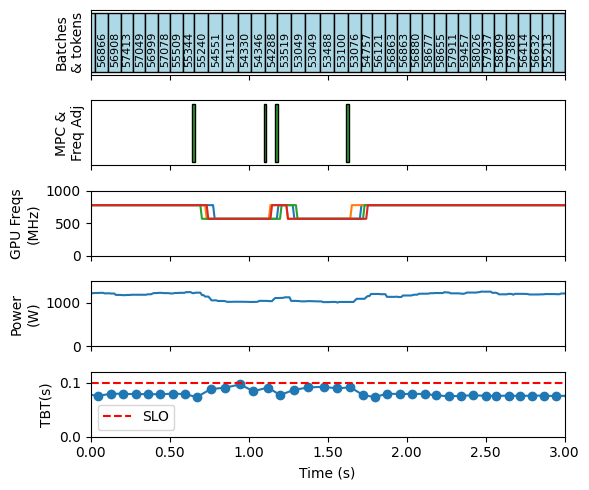

In [2]:
from matplotlib import patches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

folder = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/micro_study/profiler_logs_jan3_micro_study_logs/meta-llama/Llama-3.3-70B-Instruct/H100/2xTP2Prefill_1xTP4/DVFS_no_gc_2_2048_chunks_14krequests_30rps_0.5burstiness/decode_4_Jan03192322"
power_df = pd.read_csv(f"{folder}/power_log.csv")
engine_df = pd.read_csv(f"{folder}/engine_0.csv")
freq_mod_df = pd.read_csv(f"{folder}/freq_mod_log.csv", header=None, names=["now","mpc_start","freq_mod_start","freq_mod_end","target_freq","batch_lat","running_q_len","waiting_q_len","max_running_q_wait","max_waiting_q_wait"])
freq_mod_df = freq_mod_df[freq_mod_df["now"] != "now"].reset_index(drop=True)
freq_mod_df = freq_mod_df.astype(float)
freq_apply_df = pd.read_csv(f"{folder}/freq_apply_log_4.csv", header=None, names=["now","freq_app_time","target_freq"]).drop_duplicates()
freq_apply_df = freq_apply_df[freq_apply_df["now"] != "now"].reset_index(drop=True)

# mean power and freq accros GPUs
power_df['power_w'] = power_df[[col for col in power_df.columns if col.startswith("GPU_") and col.endswith("_power_w")]].sum(axis=1)
# power_df['freq_mhz'] = power_df[[col for col in power_df.columns if col.startswith("GPU_") and col.endswith("_freq_mhz")]].mean(axis=1)
# power_df['freq_mhz'] = power_df["GPU_1_freq_mhz"]

# parse strings to lists
engine_df['num_prompt_tokens_reqs_evald'] = engine_df['num_prompt_tokens_reqs'].apply(eval)
engine_df['inter_token_latencies_iter_evald'] = engine_df['inter_token_latencies_iter'].apply(eval)
engine_df['inter_token_latencies_iter_single'] = engine_df['inter_token_latencies_iter_evald'].apply(lambda x: x[2] if len(x) > 3 else 0)
engine_df.loc[:, "step_with_batch_queue_time_ms"] = engine_df["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

t_start = 1767468379
t_end = t_start + 3
engine_df = engine_df[(engine_df['now'] >= t_start - 1)
                                & (engine_df['now'] < t_end + 1)].reset_index(drop=True)
power_df = power_df[(power_df['Timestamp'] >= t_start - 1) & (
    power_df['Timestamp'] < t_end + 1)].reset_index(drop=True)
freq_mod_df = freq_mod_df[(freq_mod_df['now'] >= t_start - 1) & (
    freq_mod_df['now'] < t_end + 1)].reset_index(drop=True)

fig, axs = plt.subplots(5, 1, figsize=(6, 5), sharex=True, constrained_layout=True)

def format_func(x_val, _):
    return f'{x_val - t_start:.2f}'
for ax in axs:
    ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# Plot 1: Inference batch timeline (Gantt)
ax = axs[0]
for idx, row in engine_df.iterrows():
    end = row.engine_core_timestamp
    duration = row.inter_token_latencies_iter_single
    start = end - duration
    ax.add_patch(patches.Rectangle((start, 0.05), duration, 0.9, facecolor='lightblue', edgecolor='black'))
    
    # Add text to each triangle
    if start > t_start and end < t_end:
        text = np.sum(row['num_prompt_tokens_reqs_evald'])
        ax.text((start + duration / 2)+0.005, 0.4, text, ha='center', va='center', fontsize=8,
                color='black', rotation='vertical')

ax.set_ylim(0, 1)
ax.set_xlim(t_start, t_end)
ax.set_yticks([])
ax.set_ylabel("Batches\n& tokens")

# Plot 2: Frequency change intervals
ax = axs[1]
prev_freq = None
for idx, row in freq_apply_df.iterrows():
    if float(row['now']) < t_start-1 or float(row['now']) > t_end+1:
        continue
    mod_duration = float(row['now']) - float(row['freq_app_time'])
    ax.add_patch(patches.Rectangle((float(row['now']), 0.05), mod_duration, 0.9,
                                    facecolor='tab:green', edgecolor='black'))
    # ax.text(float(row['now']), 0.5, f"{int(row['target_freq'])}", 
    #         ha='center', va='center', fontsize=10, color='black', rotation='vertical')
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_ylabel("MPC &\nFreq Adj")

# Plot 3: frequency 0
ax = axs[2]
ax.plot(power_df['Timestamp'], power_df['GPU_0_freq_mhz'])
ax.plot(power_df['Timestamp'], power_df['GPU_1_freq_mhz'])
ax.plot(power_df['Timestamp'], power_df['GPU_2_freq_mhz'])
ax.plot(power_df['Timestamp'], power_df['GPU_3_freq_mhz'])
ax.set_ylabel('GPU Freqs\n(MHz)')
ax.set_ylim(0,1000)


# Plot 5: power
ax = axs[3]
ax.plot(power_df['Timestamp'], power_df['power_w'])
ax.set_ylabel('Power\n(W)')
ax.set_ylim(0, 1500)

# Plot 6: tbt
ax = axs[4]
# Filter out rows with empty sequences in 'inter_token_latencies_iter_single'
ax.plot(engine_df['now'], engine_df['inter_token_latencies_iter_single'], marker='o')
ax.set_ylabel('TBT(s)')
ax.set_ylim((0, 0.12))
ax.axhline(y=0.1, color='r', label='SLO', linestyle='--')
ax.legend()

ax.set_xlabel('Time (s)')


plt.tight_layout()
plt.savefig("figs/micro_decode.pdf", format="pdf")